Анализ данных и обучение модели для предсказания целевой переменной `CC50`

In [18]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from scipy.stats import burr, fisk, genextreme, shapiro, weibull_min
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')

In [19]:
pd.set_option('display.max_columns', None)

# 1. Загрузка и подготовка данных

## Загрузка датасета

In [20]:
train = pd.read_csv('train.csv', sep=',')

In [21]:
train.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

In [22]:
train.shape

(751, 214)

In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


Выполним переименование колонок, чтобы упростить дальнейшую работу с целевыми переменными:

In [24]:
train.rename(
    columns={
        'IC50, mM': 'IC50',
        'CC50, mM': 'CC50'
    },
    inplace=True
)

Удаляем колонку `index`, потому что это технический идентификатор, а не признак для обучения модели:

In [25]:
train = train.drop('index', axis=1)

## Пропуски

In [26]:
absences = train.isna().sum().sum()
absences_perc = absences / train.size * 100
print(f"Количество пропусков: {absences} ({absences_perc:.2f}%)")

Количество пропусков: 24 (0.02%)


Удалим полностью пустые строки, если они есть:

In [27]:
train.dropna(how='all', inplace=True)

In [28]:
absences = train.isna().sum().sum()
absences_perc = absences / train.size * 100
print(f"Количество пропусков после удаления пустых строк: {absences} ({absences_perc:.2f}%)")

Количество пропусков после удаления пустых строк: 24 (0.02%)


## Дубликаты

In [29]:
duplicates = train.duplicated().sum()
duplicates_perc = duplicates / len(train) * 100
print(f"Количество дубликатов: {duplicates} ({duplicates_perc:.2f}%)")

Количество дубликатов: 15 (2.00%)


Удалим выявленные дубликаты:

In [30]:
train.drop_duplicates(inplace=True)

In [31]:
duplicates = train.duplicated().sum()
duplicates_perc = duplicates / len(train) * 100
print(f"Количество дубликатов после удаления: {duplicates} ({duplicates_perc:.2f}%)")

Количество дубликатов после удаления: 0 (0.00%)


## Заключение

После загрузки датасета осталось 736 строк и 213 колонок: техническая колонка `index` удалена, целевые колонки переименованы в `IC50` и `CC50`, дубликаты удалены. В таблице осталось 24 пропуска, поэтому перед обучением ниже используется `dropna()`, чтобы модель обучалась только на полностью заполненных строках.

Из этого следует, что данные пригодны для дальнейшего анализа, но перед построением модели нужно отдельно проверить форму распределения `CC50`, наличие выбросов и влияние большого разброса целевой переменной на ошибку RMSE.


# 2. Анализ данных

## Параметры датасета

Список колонок:

In [32]:
train.columns

Index(['IC50', 'CC50', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=213)

Параметры датасета:

In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 736 entries, 0 to 750
Columns: 213 entries, IC50 to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.2 MB


In [34]:
train.describe()

,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.0,734.000000,734.000000,734.000000,734.000000,736.000000,736.000000,736.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,736.000000,7.360000e+02,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,7.360000e+02,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.0,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.0,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.00000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.000000,736.0

## Анализ целевой переменной

In [35]:
TARGET = 'CC50'

### Распределение

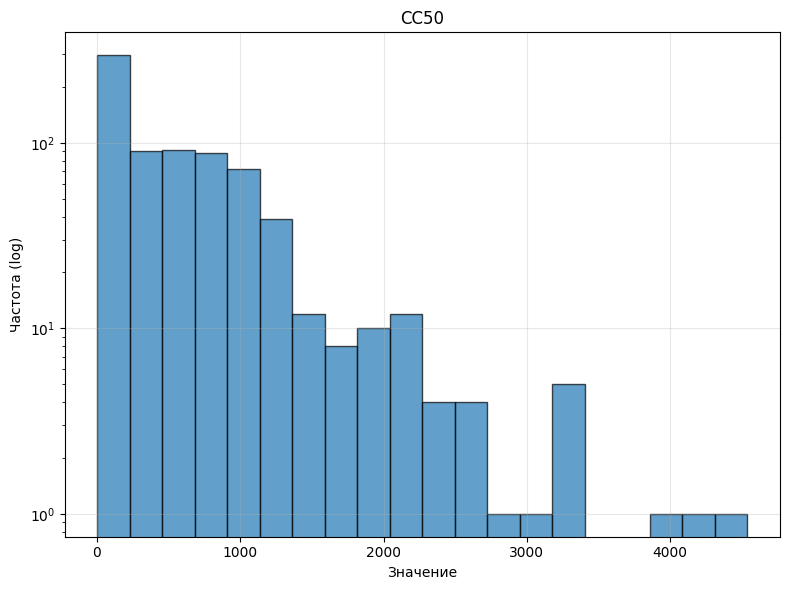

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
data = train[TARGET].dropna()

ax.hist(
    data,
    bins=20,
    alpha=0.7,
    edgecolor='black'
)
ax.set_title(TARGET, fontsize=12)
ax.set_xlabel('Значение', fontsize=10)
ax.set_ylabel('Частота (log)', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

* Распределение `CC50` правосторонне асимметрично: среднее значение (`579.28`) больше медианы (`408.79`), значит часть больших значений сдвигает среднее вправо.
* Основная масса объектов находится ниже верхнего квартиля (`878.70`), но максимум достигает `4538.98`. Это показывает, что в данных есть редкие, но очень крупные значения `CC50`.
* Из-за такого разброса RMSE будет особенно чувствителен к ошибкам на больших значениях. Поэтому дальше отдельно проверяются выбросы и распределение целевой переменной, а при обучении сравниваются простая линейная модель и более гибкие модели.


### Анализ выбросов

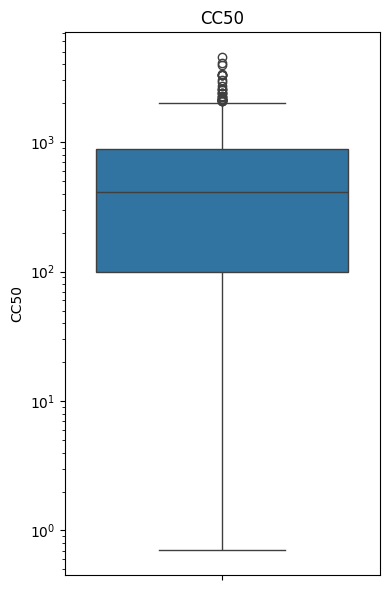

In [37]:
fig, ax = plt.subplots(figsize=(4, 6))
sns.boxplot(
    y=train[TARGET],
    ax=ax
)
ax.set_title(TARGET)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

Boxplot подтверждает вывод по гистограмме: у `CC50` есть значения, которые заметно выше основной массы наблюдений. Логарифмическая шкала нужна не для изменения данных, а для читаемой визуализации: без нее центральная часть распределения была бы сжата из-за крупных значений.

Из этого следует, что выбросы нужно не просто визуально отметить, а количественно оценить через IQR. Это позволит понять, насколько большая доля данных находится за пределами типичного диапазона.


#### Границы выбросов по IQR

In [38]:
train_clean = train.dropna()
data_positive = train_clean[TARGET]
data_positive = data_positive[data_positive > 0]

Q1 = data_positive.quantile(0.25)
Q3 = data_positive.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.4f}")
print(f"Q3={Q3:.4f}")
print(f"Нижняя граница нормальных значений: {lower_bound:.4f}")
print(f"Верхняя граница нормальных значений: {upper_bound:.4f}")

Q1=99.9990
Q3=876.3391
Нижняя граница нормальных значений: -1064.5110
Верхняя граница нормальных значений: 2040.8491


In [39]:
outlier_mask = (train_clean[TARGET] < lower_bound) | (train_clean[TARGET] > upper_bound)
outliers_count = outlier_mask.sum()
outliers_perc = outliers_count / len(train_clean) * 100

print(f"Количество выбросов по IQR: {outliers_count} ({outliers_perc:.2f}%)")

Количество выбросов по IQR: 30 (4.09%)


По правилу IQR верхняя граница типичных значений равна `2040.85`, а нижняя граница получилась отрицательной (`-1064.51`). Так как `CC50` положительная величина, нижняя граница здесь не важна, а выбросы появляются именно справа - среди слишком больших значений.

Всего найдено 30 выбросов, то есть `4.09%` очищенной выборки. Это небольшая доля данных, поэтому удалять их не будем: такие значения могут быть реальными объектами, а не ошибками. Но при оценке качества нужно учитывать, что именно они могут заметно увеличивать RMSE.


### Распределение Вейбулла

Проверим, насколько положительные значения `CC50` можно приблизить распределением Вейбулла.

In [41]:
shape_weibull, loc_weibull, scale_weibull = weibull_min.fit(data_positive, floc=0)

print(f"k={shape_weibull:.4f}")
print(f"loc={loc_weibull:.4f}")
print(f"λ={scale_weibull:.4f}")

k=0.8199
loc=0.0000
λ=521.7641


#### Теоретическая кривая

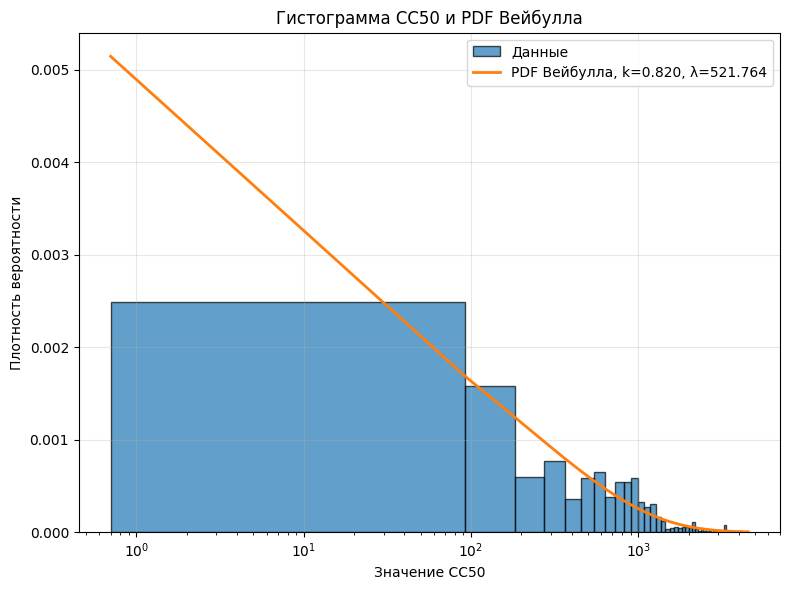

In [42]:
plt.figure(figsize=(8, 6))

count, bins, ignored = plt.hist(
    data_positive,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor='black',
    label='Данные'
)

pdf_weibull = weibull_min.pdf(
    bins,
    shape_weibull,
    loc=loc_weibull,
    scale=scale_weibull
)

plt.plot(
    bins,
    pdf_weibull,
    linewidth=2,
    label=f'PDF Вейбулла, k={shape_weibull:.3f}, λ={scale_weibull:.3f}'
)

plt.xlabel('Значение CC50')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма CC50 и PDF Вейбулла')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

Для распределения Вейбулла получены параметры `k = 0.8199` и `λ = 521.7641`. Значение `k < 1` соответствует распределению с высокой плотностью около малых значений и длинным правым хвостом, что похоже на форму `CC50`.

При этом визуально теоретическая кривая не полностью повторяет эмпирическое распределение: центральная часть и хвост описываются неточно. Поэтому одного графика недостаточно - дальше проверяем совпадение распределений через Q-Q график и критерий Колмогорова-Смирнова.


#### Q-Q график

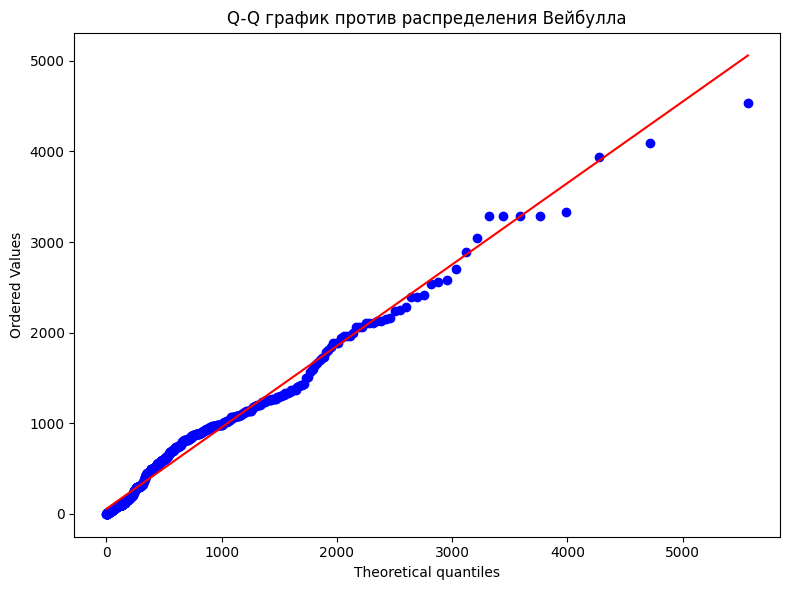

In [43]:
plt.figure(figsize=(8, 6))

weibull_dist = weibull_min(shape_weibull, loc=loc_weibull, scale=scale_weibull)
stats.probplot(
    data_positive,
    dist=weibull_dist,
    plot=plt
)
plt.title('Q-Q график против распределения Вейбулла')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

На Q-Q графике точки не ложатся на одну прямую по всей длине распределения. Особенно заметны отклонения в правой части, где находятся большие значения `CC50`. Это означает, что распределение Вейбулла частично отражает асимметрию данных, но плохо описывает хвост.

Из этого следует, что Вейбулл нельзя сразу принимать как хорошее описание целевой переменной. Нужна формальная проверка через критерий Колмогорова-Смирнова.


#### Тест Колмогорова-Смирнова

In [44]:
ks_stat_weibull, ks_pvalue_weibull = stats.kstest(
    data_positive,
    lambda x: weibull_min.cdf(
        x,
        shape_weibull,
        loc=loc_weibull,
        scale=scale_weibull
    )
)

print(f"Статистика: {ks_stat_weibull:.4f}")
print(f"p-значение: {ks_pvalue_weibull:.4f}")

Статистика: 0.0747
p-значение: 0.0005


Для интерпретации теста используется стандартное правило: если p-значение меньше 0.05, то данные статистически значимо расходятся с выбранным распределением.

### Определение статистического распределения

In [45]:
distributions_to_test = [
    (genextreme, 'Обобщенное экстремальное'),
    (burr, 'Бурра'),
    (fisk, 'Лог-логистическое')
]

for dist, name in distributions_to_test:
    params = dist.fit(data_positive.values)
    ks_stat, ks_pvalue = stats.kstest(
        data_positive.values,
        lambda x: dist.cdf(x, *params)
    )
    print(f"{name}:")
    print(f"	Статистика KS: {ks_stat:.4f}")
    print(f"	p-значение: {ks_pvalue:.4f}")

Обобщенное экстремальное:
	Статистика KS: 0.1204
	p-значение: 0.0000
Бурра:
	Статистика KS: 0.0666
	p-значение: 0.0028
Лог-логистическое:
	Статистика KS: 0.0943
	p-значение: 0.0000


По критерию Колмогорова-Смирнова ни одно из проверенных распределений не подошло достаточно хорошо: у всех `p-value < 0.05`, поэтому гипотеза о совпадении `CC50` с выбранным распределением отвергается.

Лучший результат среди трех вариантов показало распределение Бурра: `KS = 0.0666`, `p-value = 0.0028`. Его статистика KS меньше, чем у обобщенного экстремального распределения (`0.1204`) и лог-логистического распределения (`0.0943`), значит оно ближе к данным по форме. Но так как `p-value` все равно меньше `0.05`, считать его корректной моделью распределения нельзя.

Из этого следует, что `CC50` имеет сложную форму и не сводится к одному простому теоретическому распределению. Поэтому дальше задача рассматривается как регрессионная: модель будет учиться по признакам объекта, а не через заранее заданный закон распределения целевой переменной.


### Тест Шапиро-Уилка на нормальность логарифмированных данных

In [46]:
log_data = np.log(data_positive)
stat_shapiro, p_value_shapiro = shapiro(log_data)

print(f"Статистика: {stat_shapiro:.4f}")
print(f"p-значение: {p_value_shapiro:.4f}")

Статистика: 0.9195
p-значение: 0.0000


После логарифмирования нормальность также не подтвердилась: статистика Шапиро-Уилка равна `0.9195`, а `p-value = 0.0000`. Значит даже логарифмированные значения `CC50` статистически значимо отличаются от нормального распределения.

Это подтверждает, что целевая переменная остается сложной для описания простыми распределениями. Поэтому при обучении ниже не будем опираться на предположение о нормальности, а сравним модели по фактической ошибке RMSE.


## Корреляция целевой переменной с признаками

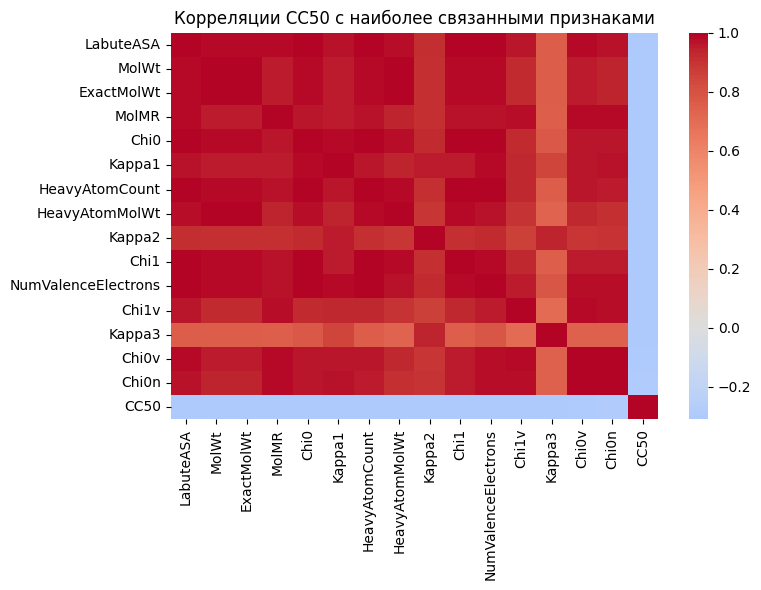

In [47]:
correlations = train_clean.corr(numeric_only=True)[TARGET]
correlations = correlations.drop(['IC50', 'SI', TARGET], errors='ignore')
top_correlations = correlations.abs().sort_values(ascending=False).head(15)
top_features = top_correlations.index.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    train_clean[top_features + [TARGET]].corr(numeric_only=True),
    cmap='coolwarm',
    center=0
)
plt.title('Корреляции CC50 с наиболее связанными признаками')
plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

Самые заметные линейные связи с `CC50` имеют признаки, связанные с размером и массой молекулы: `LabuteASA`, `MolWt`, `ExactMolWt`, `MolMR`, `Chi0`, `Kappa1`. При этом максимальная корреляция по модулю около `0.31`, то есть сильной линейной зависимости между одним признаком и целевой переменной не видно.

Большинство этих корреляций отрицательные: при росте отдельных размерных дескрипторов `CC50` в среднем уменьшается, но связь слабая/умеренная. Из этого следует, что одной линейной зависимости недостаточно, поэтому дальше стоит сравнить линейную модель с нелинейными моделями, которые могут учитывать комбинации признаков.


## Заключение

**Ключевые выводы по анализу целевой переменной `CC50`**

* После очистки для обучения остается 734 полностью заполненных строки и 210 признаков.
* `CC50` имеет правостороннюю асимметрию: среднее больше медианы, а максимум (`4538.98`) намного выше верхнего квартиля.
* По IQR найдено 30 правосторонних выбросов (`4.09%`). Их не удаляем, потому что они могут быть реальными наблюдениями, но учитываем, что они повышают RMSE.
* Проверенные теоретические распределения не подошли по критерию Колмогорова-Смирнова. Даже лучшее из них, распределение Бурра, имеет `p-value = 0.0028`, то есть статистически отвергается.
* Логарифмирование не сделало распределение нормальным (`p-value = 0.0000` по Шапиро-Уилку).
* Линейные корреляции с отдельными признаками невысокие: максимум по модулю около `0.31`.

Из этих наблюдений следует, что дальше нужно обучать и сравнивать регрессионные модели по фактической ошибке. Линейная модель будет использоваться как простой ориентир, а Random Forest и SVR - как более гибкие варианты для возможных нелинейных зависимостей.


# 3. Обучение модели

## Формирование датасета признаков

In [48]:
df = train_clean.copy()

In [49]:
exclude_cols = ['IC50', 'SI']

In [50]:
feature_cols = [
    col for col in df.columns
    if col not in [TARGET] + exclude_cols
]

In [51]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

Заполняем пропуски в признаках средними значениями:

In [52]:
X.fillna(X.mean(numeric_only=True), inplace=True)

In [53]:
print(f"Количество признаков: {X.shape[1]}")

Количество признаков: 210


## Стандартизация признаков

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Подбор оптимального количества компонент PCA

In [55]:
pca_full = PCA()
pca_full.fit(X_scaled)

PCA()

**Визуализация объясненной дисперсии**

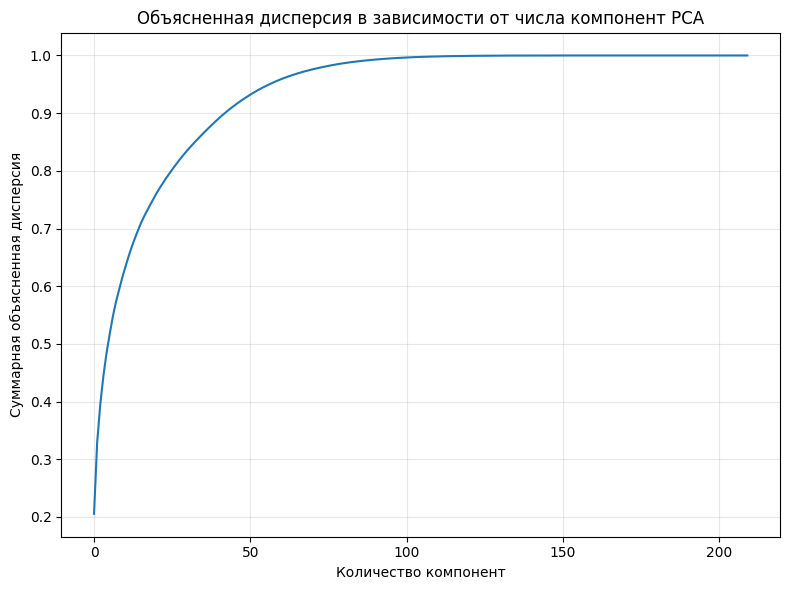

In [56]:
plt.figure(figsize=(8, 6))

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объясненная дисперсия')
plt.title('Объясненная дисперсия в зависимости от числа компонент PCA')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

До PCA в датасете 210 признаков. Кривая накопленной объясненной дисперсии показывает, что большую часть информации можно сохранить меньшим числом компонент: после первых компонент прирост дисперсии заметный, а затем кривая постепенно выходит на плато.

Из этого следует, что PCA уместен как шаг снижения размерности: он уменьшает количество входных признаков для моделей и при этом сохраняет основную часть вариативности данных. Ниже выбирается минимальное число компонент, которое объясняет 95% дисперсии.


**Выбираем количество компонент, объясняющих 95% дисперсии**

In [57]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Оптимальное количество компонент (95% дисперсии): {n_components}")

Оптимальное количество компонент (95% дисперсии): 58


In [58]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Размерность после PCA: {X_pca.shape[1]} признаков")

Размерность после PCA: 58 признаков


Для сохранения 95% дисперсии достаточно 58 компонент вместо исходных 210 признаков. То есть размерность уменьшается примерно в 3.6 раза, при этом большая часть информации из признакового пространства сохраняется.

Дальше для обучения используется именно `X_pca`, потому что модели получают более компактное представление признаков, а не все исходные 210 колонок.


## Разделение данных на обучающую и тестовую выборки

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

## Подбор модели

Зададим набор моделей и сетки параметров для `GridSearchCV`:

In [60]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False],
            'positive': [True, False]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [300, 500, 800],
            'max_depth': [20, 30, None],
            'min_samples_split': [5, 10, 20],
            'min_samples_leaf': [2, 4, 8],
            'max_features': ['sqrt', 'log2', 0.5],
            'bootstrap': [True]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    }
}

Поиск лучшей модели:

In [61]:
best_model = None
best_score = float('inf')
best_name = ''
results = {}

In [62]:
for name, config in models.items():
    print(f"Подбор параметров для {name}...")

    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': -grid_search.best_score_
    }

    print(f"	{name}: RMSE = {-grid_search.best_score_:.4f}")

    if -grid_search.best_score_ < best_score:
        best_score = -grid_search.best_score_
        best_model = grid_search.best_estimator_
        best_name = name

Подбор параметров для Linear Regression...
	Linear Regression: RMSE = 599.6578
Подбор параметров для Random Forest...
	Random Forest: RMSE = 477.5949
Подбор параметров для SVR...
	SVR: RMSE = 568.8505


In [63]:
print(f"Лучшая модель: {best_name} с RMSE = {best_score:.4f}")

Лучшая модель: Random Forest с RMSE = 477.5949


## Проверка на отложенной выборке

In [64]:
y_pred = best_model.predict(X_test)

In [65]:
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE на тестовой выборке: {test_rmse:.4f}")

RMSE на тестовой выборке: 504.7670


Сравнение с базовым подходом:

In [66]:
baseline_rmse = root_mean_squared_error(y_test, [y_train.mean()] * len(y_test))

print(f"Базовый RMSE (предсказание средним): {baseline_rmse:.4f}")
print(f"Улучшение относительно базового: {baseline_rmse - test_rmse:.4f}")

Базовый RMSE (предсказание средним): 598.4589
Улучшение относительно базового: 93.6919


Лучшей моделью стала `Random Forest`: на кросс-валидации RMSE равен `477.5949`, а на отложенной выборке - `504.7670`. Это лучше базового подхода с предсказанием средним значением (`598.4589`) на `93.6919`.

Значит модель действительно извлекает полезную информацию из признаков, а не просто повторяет средний уровень `CC50`. При этом ошибка остается достаточно большой, что согласуется с анализом выше: целевая переменная имеет сильный разброс и правосторонние выбросы.


# 4. Тестирование

## Загрузка тестового датасета

In [67]:
test_df = pd.read_csv('test.csv', index_col=[0])

In [68]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Columns: 210 entries, MaxAbsEStateIndex to fr_urea
dtypes: float64(104), int64(106)
memory usage: 412.1 KB


## Подготовка датасета

### Индексы для итогового датасета

In [69]:
test_index = test_df.index.to_frame(name='index')

In [70]:
test_index.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   index   250 non-null    int64
dtypes: int64(1)
memory usage: 3.9 KB


### Признаки

In [71]:
X_test_final = test_df[feature_cols].copy()

In [72]:
print(f"Количество признаков в тестовом датасете: {X_test_final.shape[1]}")

Количество признаков в тестовом датасете: 210


### Пропуски

In [73]:
total_nan = X_test_final.isna().sum().sum()
print(f"Всего пропусков: {total_nan}")

Всего пропусков: 12


Заполняем пропуски средними значениями:

In [74]:
X_test_final.fillna(X.mean(numeric_only=True), inplace=True)

### Стандартизация

In [75]:
X_test_scaled = scaler.transform(X_test_final)

### PCA

In [76]:
X_test_pca = pca.transform(X_test_scaled)
print(f"Размерность после PCA: {X_test_pca.shape[1]} признаков")

Размерность после PCA: 58 признаков


Тестовый датасет содержит 250 объектов и те же 210 признаков, что использовались при обучении. В тестовых признаках было 12 пропусков, они заполнены средними значениями из обучающей выборки.

После стандартизации и PCA тестовые данные имеют 58 компонент - такую же размерность, как обучающие данные после PCA. Значит признаки подготовлены согласованно, и можно переходить к финальному предсказанию `CC50`.


## Предсказание

In [77]:
y_pred_final = best_model.predict(X_test_pca)

# 5. Сохранение результатов

In [78]:
result_df = pd.DataFrame({
    'index': test_index['index'],
    'CC50': y_pred_final
})

In [79]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   250 non-null    int64  
 1   CC50    250 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 5.9 KB


In [80]:
result_df.head()

,index,CC50
index,,
0,0,605.448614
1,1,406.119473
2,2,302.002250
3,3,480.696118
4,4,340.089338


In [81]:
result_df.to_csv('predictions_cc50_2_improve_random_forest.csv', index=False)

**Итог:** сформирован файл с двумя колонками: `index` и предсказанным значением `CC50`. Колонка `index` нужна только для идентификации объектов из тестового датасета, а предсказание получено лучшей выбранной моделью после такой же подготовки признаков, как на обучающей выборке.
